# Conditional Autoencoder in the Two-Step Framework

**Docker image**: `ml4t-gpu`

**Chapter 14: Latent Factors**

> **GPU recommended**: This notebook trains PyTorch models. CPU works but is
> slow. For GPU acceleration:
> ```bash
> docker compose run --rm ml4t-gpu python 14_latent_factors/06_conditional_autoencoder.py
> ```

This notebook implements the Conditional Autoencoder (CAE) of Gu, Kelly,
and Xiu (2021) "Autoencoder Asset Pricing Models" and slots it into the
chapter's two-step factor-forecasting framework. The CAE realises Stage 1
with a *neural* characteristics-to-loadings map; the same Stage 2 forecaster
catalog used in the IPCA and RP-PCA notebooks plugs in directly.

## Prediction protocol — contemporaneous demo (read first)

This pedagogical notebook uses a **contemporaneous** prediction protocol:
characteristics $z_{i,t}$, managed-portfolio returns $x_t$, and the realized
return $r_{i,t}$ are all indexed at the same timestamp $t$. The CAE Stage 1
objective is exactly that — *reconstruct* $r_{i,t}$ from $z_{i,t}$ and $x_t$.
Stage 3 in §9 then scores the asset map $\hat\mu_{i,t} = \beta_{i,t} \cdot
\hat\lambda_t$ against the same-period $r_{i,t}$, so the reported Stage 3 IC
measures *cross-sectional rank fit of the factor reconstruction*, not
one-step-ahead forecasting skill. This number is therefore a Stage 1 fit
diagnostic on the test panel, not a tradable signal — characteristics built
from prices at $t$ already share information with the same-day return, and
the IC inherits that overlap.

The honest forecasting evaluation (lagged characteristics, walk-forward CV,
forward returns) lives in the `us_firm_characteristics` case study
(`08_latent_factors`); chapter §14.6 explicitly cites the case-study CAE
Mean IC (≈ −0.057 on `fwd_ret_1m`) as the headline number, not the
contemporaneous value shown here. Treat this notebook's §9 table as
pedagogical illustration of the framework wiring, not as evidence of CAE
forecasting performance.

## The Two-Step Framework (recap)

Asset return forecasting decomposes into three stages (see **Figure 14.9**):

1. **Stage 1 — Factor Model.** Compresses an $(T \times N)$ returns panel to
   a $(T \times K)$ factor history $F$ and a per-asset loading map. The CAE
   realises this as $r_{i,t} = \beta_{i,t}' f_t + \varepsilon$ with
   $\beta_{i,t} = g_\theta(z_{i,t})$, a neural function of stock
   characteristics, and $f_t = \mathrm{FactorNet}(x_t)$ extracted from
   *managed-portfolio* returns $x_t = (Z_t'Z_t)^{-1} Z_t' r_t$ (GKX Eq. 16).
2. **Stage 2 — Factor Premium Forecaster.** In a forward-looking deployment
   this stage predicts $\hat\lambda_{t+1}$ from the training factor history
   $F_{1:t}$; the case study runs it that way. In this notebook the same
   forecasters (Constant, AR(1), EWMA) are fit on training-window factors
   $F_{\text{train}}$ and broadcast a single $\hat\lambda$ over the test
   window — see **Figure 14.10**.
3. **Stage 3 — Asset Mapper.** Combines the factor estimate with the
   contemporaneous beta to produce a per-asset signal
   $\hat\mu_{i,t} = g_\theta(z_{i,t}) \cdot \hat\lambda$ scored against the
   same-period return $r_{i,t}$. The shift to $z_{i,t-1}$ and $r_{i,t}$ (the
   forecasting protocol) is what the case study implements.

## Why CAE? (Stage 1 contrast with PCA / IPCA)

| Method | Loadings | Loading dynamics |
|--------|----------|------------------|
| PCA    | Static $B$ | None |
| IPCA   | $\beta_{i,t} = z_{i,t}\,\Gamma$ | Linear in $z$ |
| CAE    | $\beta_{i,t} = g_\theta(z_{i,t})$ | Non-linear (NN) in $z$ |

A linear CAE with no hidden layers reduces to IPCA. The hidden ReLU layers
add capacity to learn interactions and non-linearities between
characteristics, which IPCA's bilinear specification cannot capture.

## Engel 2025 connection

Engel (2025) *"Forecasting Latent Factors of Asset Returns"*
studies exactly this framework on top of CAE: holding Stage 1 fixed at
CAE-extracted factors, swap Stage 2 between IID-BS (= our Constant), AR(1),
Q-Boost (a quantile gradient-boosting learner built on LightGBM), and a
zero-shot transformer forecaster. The reframe
in this notebook is the same idea applied symmetrically to all LF
estimators in the chapter.

## Architecture Overview (Figure 14.5, existing)

```
Characteristics Z_t              Returns r_t × Characteristics Z_t
       │                                   │
       ▼                                   ▼
[Beta Network]                  [Managed Portfolios x_t]
Dense(32) + ReLU + L1                       │
       │                                   ▼
       ▼                          [Factor Network]
   β_t (K-dim)                     Linear(K) → f_t
       │                                   │
       └──────── Dot Product ──────────────┘
                      │
                      ▼
              Predicted r̂_t
```

**Why two networks?** PCA/IPCA condition $\beta$ on a fixed function of
characteristics. The CAE's beta network is a *learned* function. The factor
network's input — managed portfolios — keeps the factor extraction
market-wide and dimension-controlled (one row per characteristic + market,
regardless of $N$).

**Why L1 on beta-net weights?** Promotes sparse loadings: each factor
concentrates on a few characteristics, mirroring the interpretability of
Fama-French-style sorts.

## Data

US Equities, top 500 by dollar volume, 5 simple characteristics computed
from prices (LME, Variance, ST_REV, r12_2, AvgRet21). For the full GKX 46
Datashop characteristics with walk-forward CV, see
[`08_latent_factors`](../case_studies/us_firm_characteristics/08_latent_factors.ipynb).

## Learning Objectives

- LO1: Recognise the CAE as a non-linear Stage 1 — same role as PCA/IPCA,
  richer functional class
- LO2: Implement the dual-network architecture in PyTorch with managed
  portfolios, ensemble training, and L1 regularisation
- LO3: Apply the Stage 2 forecaster catalog (Constant / AR(1) / EWMA) to
  the CAE factor series and observe the Stage 3 IC differences
- LO4: Read CAE-specific Stage 1 diagnostics (factor-characteristic
  correlations, beta dispersion, ensemble variance, SHAP attributions)

**Prerequisites**: PCA ([`01_pca_equity_sectors`](01_pca_equity_sectors.ipynb)),
IPCA in framework ([`04_ipca`](04_ipca.ipynb)). Requires US equities data.

**Book Reference**: Chapter 14, §14.6–14.7 (Conditional Autoencoders,
Implementation Workshop)

## 1. Setup and Imports

In [1]:
"""Conditional Autoencoder in the two-step framework — neural Stage 1, swappable Stage 2 forecasters."""

import warnings
from time import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns

import torch  # isort:skip  # must be imported before shap (CUDA runtime conflict)
import torch.nn as nn  # isort:skip
import torch.optim as optim  # isort:skip
import shap
from ml4t.diagnostic.metrics import cross_sectional_ic, cross_sectional_ic_series
from scipy.stats import spearmanr  # used for char-vs-beta correlation, not IC

warnings.filterwarnings("ignore")

from data import load_us_equities
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

### Universe-Size Scaling

CAE training cost scales as $O(\text{N\_EPOCHS} \cdot T \cdot
\text{TOP\_N\_STOCKS} \cdot d_{\text{char}})$ per ensemble member, plus
`ENSEMBLE_SIZE` parallel fits. The default 500-stock × 200-epoch × 5-member
configuration runs ~4 minutes on the local 3090. Halving `TOP_N_STOCKS` to 250
(or `ENSEMBLE_SIZE` to 1 for a quick smoke) cuts wall-time linearly. CPU-only
runs are 10–30× slower; the Papermill CI override drops `N_EPOCHS` and
`ENSEMBLE_SIZE` rather than the universe size to preserve the cross-sectional
structure the autoencoder needs to learn.

In [2]:
# Production defaults (Papermill overrides for CI testing)
TOP_N_STOCKS = 500
N_FACTORS = 5
N_EPOCHS = 200
BATCH_SIZE = 10000
ENSEMBLE_SIZE = 5
LEARNING_RATE = 0.001
LAMBDA_L1 = 0.001
SEED = 42

In [3]:
set_global_seeds(SEED)
RANDOM_SEED = SEED
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

print(
    f"Device: {device}, {TOP_N_STOCKS} stocks, {N_FACTORS} factors, {N_EPOCHS} epochs, ensemble={ENSEMBLE_SIZE}"
)

Device: cuda, 500 stocks, 5 factors, 200 epochs, ensemble=5


## 2. Data Loading

Load US Equities and compute a small panel of characteristics — a
pedagogical 5-feature subset of the GKX 46-characteristic dataset.

### Load and filter US equities data

In [4]:
equities = load_us_equities(start_date="2005-01-01", end_date="2018-03-27")

dollar_volume = (
    equities.group_by("symbol")
    .agg(
        pl.col("adj_close").mean().alias("avg_price"),
        pl.col("volume").mean().alias("avg_volume"),
        pl.col("timestamp").count().alias("n_days"),
    )
    .with_columns((pl.col("avg_price") * pl.col("avg_volume")).alias("dollar_volume"))
    .filter(pl.col("n_days") >= 252)
    .sort("dollar_volume", descending=True)
)
selected_assets = dollar_volume.head(TOP_N_STOCKS)["symbol"].to_list()
equities = equities.filter(pl.col("symbol").is_in(selected_assets))

print(f"Loaded {len(equities):,} rows for {len(selected_assets)} assets")

Loaded 1,510,866 rows for 500 assets


### Compute characteristics

Five characteristics that proxy well-known risk factors:

- **LME**: Log market equity (size proxy)
- **Variance**: 21-day rolling volatility
- **ST_REV**: Short-term reversal (21-day return)
- **r12_2**: Momentum (12-month minus 1-month return)
- **AvgRet21**: Mean return over 21 days

In [5]:
equities_sorted = equities.sort(["symbol", "timestamp"])
equities_chars = (
    equities_sorted.with_columns(
        pl.col("adj_close").pct_change().over("symbol").alias("return"),
        (pl.col("adj_close") * pl.col("volume")).alias("dollar_vol"),
    )
    .with_columns(
        pl.col("dollar_vol").log().rolling_mean(window_size=21).over("symbol").alias("LME"),
        pl.col("return").rolling_std(window_size=21).over("symbol").alias("Variance"),
        pl.col("adj_close").pct_change(n=21).over("symbol").alias("ST_REV"),
        (
            pl.col("adj_close") / pl.col("adj_close").shift(252)
            - 1
            - pl.col("adj_close").pct_change(n=21)
        )
        .over("symbol")
        .alias("r12_2"),
        pl.col("return").rolling_mean(window_size=21).over("symbol").alias("AvgRet21"),
    )
    .drop_nulls(subset=["return", "LME", "Variance", "ST_REV", "r12_2", "AvgRet21"])
)

char_names = ["LME", "Variance", "ST_REV", "r12_2", "AvgRet21"]
print(f"Computed {len(char_names)} characteristics: {char_names}")
print(f"After dropping nulls: {len(equities_chars):,} observations")

Computed 5 characteristics: ['LME', 'Variance', 'ST_REV', 'r12_2', 'AvgRet21']
After dropping nulls: 1,384,866 observations


**Note on data limitations**: The US Equities universe may contain
survivorship bias — delisted stocks are excluded, potentially inflating
apparent predictability. The chapter text (Section 14.6) discusses microcap
sensitivity in detail.

### Rank-normalise and split into train/valid/test

In [6]:
equities_pd = equities_chars.to_pandas()
equities_pd["timestamp"] = pd.to_datetime(equities_pd["timestamp"])
equities_pd = equities_pd.set_index(["timestamp", "symbol"])

features = equities_pd[char_names]
returns = equities_pd["return"]

# Rank-normalise characteristics cross-sectionally
features = features.groupby(level="timestamp").rank(pct=True) - 0.5

Final year held out for testing; six months before that for early-stopping
validation; the rest is training.

In [7]:
train_end = features.index.get_level_values("timestamp").max() - pd.Timedelta(days=365)
valid_end = features.index.get_level_values("timestamp").max() - pd.Timedelta(days=180)

data = {
    "train": {
        "characteristics": features.loc[features.index.get_level_values("timestamp") < train_end],
        "returns": returns.loc[returns.index.get_level_values("timestamp") < train_end],
    },
    "valid": {
        "characteristics": features.loc[
            (features.index.get_level_values("timestamp") >= train_end)
            & (features.index.get_level_values("timestamp") < valid_end)
        ],
        "returns": returns.loc[
            (returns.index.get_level_values("timestamp") >= train_end)
            & (returns.index.get_level_values("timestamp") < valid_end)
        ],
    },
    "test": {
        "characteristics": features.loc[features.index.get_level_values("timestamp") >= valid_end],
        "returns": returns.loc[returns.index.get_level_values("timestamp") >= valid_end],
    },
}

n_characteristics = len(char_names)
for split in data:
    print(f"  {split}: {len(data[split]['returns']):,} observations")
print(f"Using {n_characteristics} characteristics: {char_names}")

  train: 1,275,778 observations
  valid: 56,632 observations
  test: 52,456 observations
Using 5 characteristics: ['LME', 'Variance', 'ST_REV', 'r12_2', 'AvgRet21']


## 3. Stage 1 Component — Managed Portfolios (GKX Eq. 16)

The factor network needs market-wide information without exploding with $N$.
We project returns onto characteristic space using *managed portfolios*:

$$x_t = (Z_t'Z_t)^{-1} Z_t' r_t$$

Each managed portfolio's return is a zero-cost long-short strategy weighted
by one characteristic. Conditioning on characteristics extracts market-wide
factor returns without needing stock identities. The factor network learns
which linear combinations of these portfolio returns best explain the
cross-section.

In [8]:
def get_managed_portfolios(characteristics, returns):
    """Compute managed portfolios per GKX Equation 16: x_t = (Z'Z)^{-1} Z' r_t.

    Adds an all-ones "market" column. Returns one row per timestamp with K =
    n_characteristics + 1 columns.
    """
    chars_with_market = characteristics.assign(market=1)
    numerator = chars_with_market.mul(returns, axis=0).groupby(level="timestamp").sum()
    denominator = chars_with_market.pow(2).groupby(level="timestamp").sum()
    return numerator.div(denominator)

In [9]:
print("Computing managed portfolios...")
for split in data:
    data[split]["portfolios"] = get_managed_portfolios(
        data[split]["characteristics"], data[split]["returns"]
    )
    dates = data[split]["returns"].index.get_level_values("timestamp")
    data[split]["portfolios_aligned"] = data[split]["portfolios"].reindex(dates)
    print(f"  {split} portfolios: {data[split]['portfolios'].shape}")

n_instruments = data["train"]["portfolios"].shape[1]
print(f"\nManaged portfolios: {n_instruments} instruments (characteristics + market)")

Computing managed portfolios...


  train portfolios: (2826, 6)
  valid portfolios: (130, 6)
  test portfolios: (123, 6)

Managed portfolios: 6 instruments (characteristics + market)


## 4. Stage 1 Component — CAE Architecture

The CAE has two networks that meet at a dot product:

1. **Beta Network** $g_\theta : Z \to \mathbb{R}^K$ — characteristics to
   factor loadings. Hidden ReLU layers + L1-regularised weights for
   sparsity.
2. **Factor Network** $\mathrm{FactorNet} : x \to \mathbb{R}^K$ — managed
   portfolios to factor returns. Single linear layer (no activation).

Output: $\hat r_{i,t} = g_\theta(z_{i,t}) \cdot \mathrm{FactorNet}(x_t)$.

### Beta Network — characteristics → factor loadings

> **Library shortcut**: This class is also available as
> `from case_studies.config.cae.cae import ConditionalAutoencoder` for use
> outside this notebook. The inline definition below is shown for
> pedagogical exposition.

In [10]:
class BetaNetwork(nn.Module):
    """Beta Network: maps characteristics to factor loadings."""

    def __init__(self, n_characteristics: int, n_factors: int, hidden_units: tuple = (32,)):
        super().__init__()

        layers = []
        in_features = n_characteristics

        for units in hidden_units:
            layers.append(nn.Linear(in_features, units))
            layers.append(nn.BatchNorm1d(units))
            layers.append(nn.ReLU())
            in_features = units

        layers.append(nn.Linear(in_features, n_factors))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

### Factor Network — managed portfolios → factor returns

In [11]:
class FactorNetwork(nn.Module):
    """Factor Network: maps managed portfolio returns to factor returns."""

    def __init__(self, n_instruments: int, n_factors: int):
        super().__init__()
        self.linear = nn.Linear(n_instruments, n_factors, bias=False)

    def forward(self, x):
        return self.linear(x)

### Conditional Autoencoder — joins both networks via dot product

In [12]:
class ConditionalAutoencoder(nn.Module):
    """Dual-network CAE per GKX (2021): predicted return = β(z) · f(x)."""

    def __init__(
        self,
        n_characteristics: int,
        n_instruments: int,
        n_factors: int = 6,
        hidden_units: tuple = (32,),
    ):
        super().__init__()

        self.n_factors = n_factors
        self.n_characteristics = n_characteristics
        self.n_instruments = n_instruments

        self.beta_net = BetaNetwork(n_characteristics, n_factors, hidden_units)
        self.factor_net = FactorNetwork(n_instruments, n_factors)

    def forward(self, characteristics, portfolios):
        betas = self.beta_net(characteristics)
        factors = self.factor_net(portfolios)
        return (betas * factors).sum(dim=1)

    def get_betas(self, characteristics):
        """Stage 1 / Stage 3 helper: extract per-stock factor loadings."""
        return self.beta_net(characteristics)

    def get_factors(self, portfolios):
        """Stage 1 helper: extract market-wide factor returns from managed portfolios."""
        return self.factor_net(portfolios)

## 5. Stage 1 Training Utilities

In [13]:
def prepare_tensors(data_split, device):
    """Convert data split to PyTorch tensors."""
    chars = torch.tensor(data_split["characteristics"].values, dtype=torch.float32).to(device)
    portfolios = torch.tensor(data_split["portfolios_aligned"].values, dtype=torch.float32).to(
        device
    )
    returns = torch.tensor(data_split["returns"].values, dtype=torch.float32).to(device)
    return chars, portfolios, returns

In [14]:
def l1_regularization(model, lambda_l1=0.001):
    """L1 penalty on beta-network weights — drives sparse factor loadings."""
    l1_loss = 0
    for name, param in model.beta_net.named_parameters():
        if "weight" in name:
            l1_loss += param.abs().sum()
    return lambda_l1 * l1_loss

In [15]:
def compute_metrics(returns_arr, predictions_arr, period_idx, symbols=None):
    """Per-date Spearman IC summary + pooled R² over flat (n_obs,) arrays.

    Returns dict with keys: ic_mean, ic_std, ic_t, p_value, pct_positive,
    ic_ir, n_periods, r2.
    """
    nan_summary = {
        "ic_mean": np.nan,
        "ic_std": np.nan,
        "ic_t": np.nan,
        "p_value": np.nan,
        "pct_positive": np.nan,
        "ic_ir": np.nan,
        "n_periods": 0,
        "r2": np.nan,
    }
    mask = np.isfinite(returns_arr) & np.isfinite(predictions_arr)
    if mask.sum() < 10:
        return nan_summary
    r = returns_arr[mask]
    p = predictions_arr[mask]
    pi = np.asarray(period_idx)[mask]
    sy = np.arange(mask.sum()) if symbols is None else np.asarray(symbols)[mask]
    df = pl.DataFrame({"date": pi, "symbol": sy, "y_pred": p, "y_true": r})
    summary = cross_sectional_ic(
        predictions=df,
        returns=df,
        pred_col="y_pred",
        ret_col="y_true",
        date_col="date",
        entity_col="symbol",
        method="spearman",
        min_obs=5,
    )
    ss_res = np.sum((r - p) ** 2)
    ss_tot = np.sum((r - r.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
    return {**summary, "r2": float(r2)}

## 6. Stage 1 Training — CAE Ensemble

In [16]:
hidden_units = (32,)

print(
    f"Model: {N_FACTORS} factors, hidden={hidden_units}, {N_EPOCHS} epochs, ensemble={ENSEMBLE_SIZE}"
)

Model: 5 factors, hidden=(32,), 200 epochs, ensemble=5


In [17]:
train_chars, train_portfolios, train_returns = prepare_tensors(data["train"], device)
valid_chars, valid_portfolios, valid_returns = prepare_tensors(data["valid"], device)
test_chars, test_portfolios, test_returns = prepare_tensors(data["test"], device)

# Per-obs (timestamp, symbol) indexing for cross-sectional IC during training and eval.
valid_dates_idx = data["valid"]["returns"].index.get_level_values("timestamp").factorize()[0]
valid_symbols_idx = data["valid"]["returns"].index.get_level_values("symbol").factorize()[0]

print(f"\nTraining data: {train_chars.shape[0]:,} observations")
print(f"Validation data: {valid_chars.shape[0]:,} observations")
print(f"Test data: {test_chars.shape[0]:,} observations")


Training data: 1,275,778 observations


Validation data: 56,632 observations
Test data: 52,456 observations


### Train one CAE with early stopping

Each ensemble member uses a different seed. Different initialisations and
minibatch orderings produce slightly different $\beta$ networks and factor
series; averaging across members reduces variance.

In [18]:
def train_single_model(model_no, verbose=True):
    """Train one CAE ensemble member with early stopping on validation MSE."""
    if verbose:
        print(f"\n{'=' * 50}")
        print(f"Training model {model_no}/{ENSEMBLE_SIZE}")
        print("=" * 50)

    torch.manual_seed(RANDOM_SEED + model_no)

    model = ConditionalAutoencoder(
        n_characteristics=n_characteristics,
        n_instruments=n_instruments,
        n_factors=N_FACTORS,
        hidden_units=hidden_units,
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.MSELoss()

    history = {"train_loss": [], "val_loss": [], "val_ic": []}
    best_val_loss = float("inf")
    patience = 50
    patience_counter = 0
    best_state = None

    start_time = time()
    n_train = len(train_returns)

    for epoch in range(N_EPOCHS):
        model.train()
        indices = torch.randperm(n_train)
        epoch_loss = 0.0
        n_batches = 0

        for i in range(0, n_train, BATCH_SIZE):
            batch_idx = indices[i : i + BATCH_SIZE]
            batch_chars = train_chars[batch_idx]
            batch_portfolios = train_portfolios[batch_idx]
            batch_returns = train_returns[batch_idx]

            optimizer.zero_grad()
            pred = model(batch_chars, batch_portfolios)
            loss = criterion(pred, batch_returns) + l1_regularization(model, LAMBDA_L1)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        train_loss = epoch_loss / n_batches
        history["train_loss"].append(train_loss)

        model.eval()
        with torch.no_grad():
            val_pred = model(valid_chars, valid_portfolios)
            val_loss = criterion(val_pred, valid_returns).item()
            history["val_loss"].append(val_loss)

            val_pred_np = val_pred.cpu().numpy()
            val_returns_np = valid_returns.cpu().numpy()
            val_metrics = compute_metrics(
                val_returns_np, val_pred_np, valid_dates_idx, valid_symbols_idx
            )
            history["val_ic"].append(val_metrics["ic_mean"])

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = model.state_dict().copy()
        else:
            patience_counter += 1

        if patience_counter >= patience:
            if verbose:
                print(f"  Early stopping at epoch {epoch + 1}")
            break

        if verbose and (epoch + 1) % 20 == 0:
            elapsed = time() - start_time
            print(
                f"  Epoch {epoch + 1:3d} | "
                f"Train: {train_loss:.6f} | Val: {val_loss:.6f} | "
                f"IC: {val_metrics['ic_mean']:.4f} | Time: {elapsed:.1f}s"
            )

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

### Train the ensemble

In [19]:
models = []
histories = []

for model_no in range(1, ENSEMBLE_SIZE + 1):
    model, history = train_single_model(model_no)
    models.append(model)
    histories.append(history)

print(f"\nTrained {len(models)} ensemble members.")


Training model 1/5


  Epoch  20 | Train: 0.000611 | Val: 0.028160 | IC: 0.0152 | Time: 3.0s


  Epoch  40 | Train: 0.000611 | Val: 0.028160 | IC: -0.0020 | Time: 6.0s


  Epoch  60 | Train: 0.000611 | Val: 0.028160 | IC: 0.0040 | Time: 8.9s


  Epoch  80 | Train: 0.000611 | Val: 0.028160 | IC: 0.0376 | Time: 11.8s


...

  Early stopping at epoch 130

Training model 5/5


  Epoch  20 | Train: 0.000613 | Val: 0.028160 | IC: -0.0189 | Time: 3.0s


  Epoch  40 | Train: 0.000613 | Val: 0.028160 | IC: -0.0217 | Time: 5.8s


  Epoch  60 | Train: 0.000612 | Val: 0.028160 | IC: -0.0320 | Time: 9.1s


  Early stopping at epoch 76

Trained 5 ensemble members.


## 7. Stage 1 Outputs — Factor Series and Loading Maps

After training, every ensemble member exposes two Stage 1 artefacts that
downstream stages consume:

- **$F_{\text{train}}^{(m)} \in \mathbb{R}^{T_{\text{train}} \times K}$** — the
  training-window factor history, one row per trading day.
- **$\beta^{(m)}_{i,t} = g_{\theta^{(m)}}(z_{i,t}) \in \mathbb{R}^K$** — the
  per-stock loadings, evaluated at any date by passing characteristics
  through the beta network.

Stage 2 fits forecasters to $F_{\text{train}}^{(m)}$; Stage 3 multiplies
$\beta^{(m)}_{i,t}$ by $\hat\lambda_{t+1}$. The asset-level prediction is
therefore a per-member quantity; we average across members at the end of
Stage 3.

In [20]:
# Build the unique training-window managed-portfolio sequence (T_train rows).
train_portfolios_unique = data["train"]["portfolios"].dropna()
train_portfolios_unique_t = torch.tensor(train_portfolios_unique.values, dtype=torch.float32).to(
    device
)

member_outputs = []
for m, model in enumerate(models):
    model.eval()
    with torch.no_grad():
        f_train_m = model.get_factors(train_portfolios_unique_t).cpu().numpy()
        betas_test_m = model.get_betas(test_chars).cpu().numpy()
        betas_train_m = model.get_betas(train_chars).cpu().numpy()
    member_outputs.append(
        {
            "F_train": f_train_m,
            "betas_test": betas_test_m,
            "betas_train": betas_train_m,
        }
    )

print(f"F_train per member: shape {member_outputs[0]['F_train'].shape}  (T_train days × K factors)")
print(
    f"β per test obs (per member): shape {member_outputs[0]['betas_test'].shape}  (n_test_obs × K)"
)

# Ensemble-averaged β at test obs (used for Stage 1 diagnostics in §10).
ensemble_betas = np.mean([m["betas_test"] for m in member_outputs], axis=0)

F_train per member: shape (2826, 5)  (T_train days × K factors)
β per test obs (per member): shape (52456, 5)  (n_test_obs × K)


## 8. Stage 2 — Factor Premium Forecasters

Stage 2 takes the training factor history $F_{1:T}$ and emits a one-step-ahead
factor-premium forecast $\hat\lambda_{t+1} \in \mathbb{R}^K$. We implement
three Tier-1 forecasters from the catalog (**Figure 14.10**).

**Constant** (the implicit choice in GKX 2021, = Engel 2025's IID-BS):
$$\hat\lambda_{t+1} = \frac{1}{T}\sum_{s=1}^{T} f_s$$

**AR(1)** (per-factor first-order autoregression):
$$\hat\lambda_{k,t+1} = c_k + \phi_k\, f_{k,t}$$

**EWMA** (exponentially weighted average, half-life $h = 60$ trading days
≈ 12 weeks for daily data):
$$\hat\lambda_{k,t+1} = (1 - \alpha)\sum_{s=1}^{T} \alpha^{T-s}\, f_{k,s},
\quad \alpha = \exp(-\ln 2 / h)$$

All three are **paper-faithful in shape** with the IPCA and RP-PCA
notebooks — the forecaster API does not depend on which Stage 1 produced
$F_{1:T}$.

In [21]:
class ConstantForecaster:
    """Sample mean of training factors (= GKX 2021 implicit, Engel 2025 IID-BS)."""

    def fit(self, F: np.ndarray) -> "ConstantForecaster":
        self.lam_ = F.mean(axis=0)
        return self

    def predict(self, n_steps: int) -> np.ndarray:
        return np.tile(self.lam_, (n_steps, 1))

In [22]:
class AR1Forecaster:
    """Per-factor AR(1): λ̂_{k,t+1} = c_k + φ_k · f_{k,t}."""

    def fit(self, F: np.ndarray) -> "AR1Forecaster":
        K = F.shape[1]
        self.c_ = np.zeros(K)
        self.phi_ = np.zeros(K)
        for k in range(K):
            x = F[:-1, k]
            y = F[1:, k]
            phi, c = np.polyfit(x, y, deg=1)
            self.phi_[k] = phi
            self.c_[k] = c
        self.last_ = F[-1]
        return self

    def predict(self, n_steps: int) -> np.ndarray:
        out = np.zeros((n_steps, len(self.last_)))
        prev = self.last_.copy()
        for s in range(n_steps):
            prev = self.c_ + self.phi_ * prev
            out[s] = prev
        return out

In [23]:
class EWMAForecaster:
    """EWMA with half-life h periods (default 60 daily ≈ 12-week half-life)."""

    def __init__(self, half_life: float = 60.0):
        self.half_life = half_life

    def fit(self, F: np.ndarray) -> "EWMAForecaster":
        T = len(F)
        alpha = np.exp(-np.log(2) / self.half_life)
        weights = alpha ** np.arange(T - 1, -1, -1)
        weights /= weights.sum()
        self.lam_ = (weights[:, None] * F).sum(axis=0)
        return self

    def predict(self, n_steps: int) -> np.ndarray:
        return np.tile(self.lam_, (n_steps, 1))

### Inspect Stage 2 fits on member 1

A quick sanity check before running Stage 3 across the ensemble: fit each
forecaster on the first ensemble member's $F_{\text{train}}$ and read off
the predicted $\hat\lambda$ for the first test period.

In [24]:
test_periods = data["test"]["portfolios"].dropna().index
n_test_periods = len(test_periods)

F_train_m0 = member_outputs[0]["F_train"]
demo_forecasters = {
    "Constant": ConstantForecaster().fit(F_train_m0),
    "AR(1)": AR1Forecaster().fit(F_train_m0),
    "EWMA(h=60)": EWMAForecaster(half_life=60.0).fit(F_train_m0),
}
for name, f in demo_forecasters.items():
    lam0 = f.predict(1)[0]
    print(f"  {name:12s}  λ̂_1 = {lam0.round(6)}")

  Constant      λ̂_1 = [-0.005446  0.00024  -0.001498  0.001499  0.01699 ]
  AR(1)         λ̂_1 = [-0.005264  0.000232 -0.00151   0.001392  0.016351]
  EWMA(h=60)    λ̂_1 = [-0.00524   0.000405 -0.001203  0.001926  0.014659]


**Reading the numbers**: Constant collapses the entire training history to
a single vector (the sample mean). EWMA(h=60) puts weight ≈ 50% on the
last 60 days, giving a faster-moving estimate of what factors are paying
right now. AR(1) starts from the most recent factor value and iterates
forward via per-factor coefficients — its forecast evolves with $t$, while
Constant and EWMA are flat across the test window.

## 9. Stage 3 — Asset Prediction Across Forecasters

Stage 3 combines the factor estimate $\hat\lambda$ with the contemporaneous
beta to produce a per-asset signal $\hat\mu_{i,t} = \beta_{i,t} \cdot
\hat\lambda$. For the CAE, $\beta_{i,t} = g_\theta(z_{i,t})$ — the beta
network evaluated at the stock's characteristics on date $t$. As the
preamble protocol note flagged, this notebook scores $\hat\mu_{i,t}$ against
the *same-period* return $r_{i,t}$; the resulting IC measures
cross-sectional rank fit of the factor reconstruction, not forecasting
skill. The walk-forward forecasting evaluation lives in the
`us_firm_characteristics` case study.

We loop over forecasters, then over ensemble members, and average the
member-level $\hat\mu$ surfaces. This parallels how GKX 2021 use ensemble
averaging to reduce variance in single-model neural-network predictions.

In [25]:
# Map each test obs to its period index in [0, n_test_periods).
test_obs_dates = data["test"]["returns"].index.get_level_values("timestamp")
test_period_index = pd.Index(test_periods)
obs_period_idx = test_period_index.get_indexer(test_obs_dates)
assert (obs_period_idx >= 0).all(), "all test obs should map to a known test period"

forecaster_factories = {
    "Constant": lambda: ConstantForecaster(),
    "AR(1)": lambda: AR1Forecaster(),
    "EWMA(h=60)": lambda: EWMAForecaster(half_life=60.0),
}

mu_hat_by_forecaster = {}
mu_hat_per_member = {name: [] for name in forecaster_factories}

for fname, fcls in forecaster_factories.items():
    for mem in member_outputs:
        # Stage 2: fit Tier-1 forecaster on this member's F_train.
        forecaster = fcls()
        forecaster.fit(mem["F_train"])
        lam_periods = forecaster.predict(n_test_periods)  # (T_test, K)

        # Stage 3: broadcast λ̂_t to per-obs vectors and dot with β.
        lam_per_obs = lam_periods[obs_period_idx]  # (n_obs, K)
        mu_hat_member = (mem["betas_test"] * lam_per_obs).sum(axis=1)  # (n_obs,)
        mu_hat_per_member[fname].append(mu_hat_member)

    mu_hat_by_forecaster[fname] = np.mean(mu_hat_per_member[fname], axis=0)

print("Stage 3 complete — ensemble-averaged μ̂ available per forecaster.")

Stage 3 complete — ensemble-averaged μ̂ available per forecaster.


### Score forecasters by per-date Spearman IC

Headline IC is the **per-date cross-sectional Spearman rank correlation**
averaged across test periods. Reporting Mean IC alongside IC IR (mean/std,
non-annualised), t-stat, and p-value follows the same convention used by
the chapter case studies and by Ch7's IC introduction. We also report
pooled OOS R² so reconstruction quality is visible separately from rank IC.

In [26]:
def per_period_ic(predictions, actuals, period_idx, symbols=None):
    """Per-date Spearman IC series via the diagnostic library."""
    mask = np.isfinite(actuals) & np.isfinite(predictions)
    if mask.sum() < 20:
        return np.array([])
    pi = np.asarray(period_idx)[mask]
    sy = np.arange(mask.sum()) if symbols is None else np.asarray(symbols)[mask]
    df = pl.DataFrame(
        {"date": pi, "symbol": sy, "y_pred": predictions[mask], "y_true": actuals[mask]}
    )
    series = cross_sectional_ic_series(
        predictions=df,
        returns=df,
        pred_col="y_pred",
        ret_col="y_true",
        date_col="date",
        entity_col="symbol",
        method="spearman",
        min_obs=20,
    )
    return series.drop_nulls("ic")["ic"].to_numpy()


test_returns_np = test_returns.cpu().numpy()
test_symbols_idx = data["test"]["returns"].index.get_level_values("symbol").factorize()[0]

results_rows = []
ic_series_by_forecaster = {}
for fname, mu_hat in mu_hat_by_forecaster.items():
    summary = compute_metrics(test_returns_np, mu_hat, obs_period_idx, test_symbols_idx)
    ic_series_by_forecaster[fname] = per_period_ic(
        mu_hat, test_returns_np, obs_period_idx, test_symbols_idx
    )
    results_rows.append(
        {
            "Forecaster": fname,
            "Mean IC": f"{summary['ic_mean']:.4f}",
            "IC IR": f"{summary['ic_ir']:.4f}",
            "t-stat": f"{summary['ic_t']:.2f}",
            "p-value": f"{summary['p_value']:.3f}",
            "R²": f"{summary['r2']:.5f}",
            "Periods": int(summary["n_periods"]),
        }
    )

pl.DataFrame(results_rows)

Forecaster,Mean IC,IC IR,t-stat,p-value,R²,Periods
str,str,str,str,str,str,i64
"""Constant""","""0.0189""","""0.1524""","""1.69""","""0.094""","""-0.00010""",123
"""AR(1)""","""-0.0423""","""-0.4143""","""-4.59""","""0.000""","""-0.00010""",123
"""EWMA(h=60)""","""-0.0493""","""-0.4857""","""-5.39""","""0.000""","""-0.00003""",123


### Cache Stage 3 Predictions

Save the stacked long-form prediction frame so re-running the visualisation
and ensemble-decomposition cells doesn't re-train the CAE ensemble. Cache
key includes the universe size, factor count, training schedule, and the
forecaster set; see `utils/predictions_cache.py` for the contract.

In [27]:
from utils.predictions_cache import predictions_cache_key, save_predictions

predictions_spec = {
    "notebook": "cae",
    "data": {
        "source": "us_equities",
        "top_n_stocks": TOP_N_STOCKS,
    },
    "model": {
        "name": "conditional_autoencoder",
        "n_factors": N_FACTORS,
        "n_epochs": N_EPOCHS,
        "batch_size": BATCH_SIZE,
        "ensemble_size": ENSEMBLE_SIZE,
        "learning_rate": LEARNING_RATE,
        "lambda_l1": LAMBDA_L1,
    },
    "forecasters": list(mu_hat_by_forecaster.keys()),
}

stacked_frames = []
for fname, mu_hat in mu_hat_by_forecaster.items():
    mask = np.isfinite(test_returns_np) & np.isfinite(mu_hat)
    stacked_frames.append(
        pl.DataFrame(
            {
                "date": np.asarray(obs_period_idx)[mask],
                "symbol": np.asarray(test_symbols_idx)[mask],
                "y_pred": mu_hat[mask].astype(np.float64),
                "y_true": test_returns_np[mask].astype(np.float64),
                "forecaster": np.full(mask.sum(), fname),
            }
        )
    )
stacked = pl.concat(stacked_frames)
save_predictions(chapter=14, notebook_id="cae", spec=predictions_spec, frame=stacked)
print(f"Cached {len(stacked):,} rows under key {predictions_cache_key(predictions_spec)}")

Cached 157,368 rows under key 464fcb998af5


**Reading the table**: The three forecasters do *not* land at the same place
on this panel. The Constant forecaster yields a small positive Mean IC
$\approx 0.019$ (IC IR $\approx 0.15$, $t \approx 1.7$, $p \approx 0.09$ —
not significant), while AR(1) and EWMA both produce significantly *negative*
contemporaneous IC ($\approx -0.042$ and $-0.049$, $t \approx -4.6$ and
$-5.4$) over 123 test periods. Two reading caveats: (1) this is the
contemporaneous protocol described in the preamble — $\hat\mu_{i,t}$ is scored
against $r_{i,t}$, so the IC measures Stage 1 reconstruction quality and
overstates what the framework can deliver one step ahead; characteristics
built from prices at $t$ share mechanical overlap with the same-day return.
(2) Stage 2 choice is *not* irrelevant here: the Constant forecaster holds
the training-factor mean, while the dynamic forecasters (AR(1), EWMA)
extrapolate the factor paths in a way that flips the sign of the test-window
reconstruction. The
pooled OOS $R^2$ is essentially zero ($\approx -10^{-5}$) because the
variance of one-day returns is dominated by an idiosyncratic component the
model does not try to predict. The
[`us_firm_characteristics`](../case_studies/us_firm_characteristics/08_latent_factors.ipynb)
case study with GKX 46 characteristics, walk-forward CV, lagged
characteristics, and forward returns is where the honest forecasting IC is
reported (≈ $-0.057$ on `fwd_ret_1m`); the contrast with the
contemporaneous IC here makes the protocol distinction concrete.

### Engel 2025 connection

Engel (2025) runs exactly this pairing on monthly CAE
factors with Q-Boost (a quantile gradient-boosting learner built on
LightGBM) and ZS-Chronos (a zero-shot transformer forecaster) added on top
of IID-BS / AR(1). The key empirical claim of the paper: Tier-2/3
forecasters add measurable signal *only when the factors carry forecastable
structure*. On daily US-equity factor returns extracted from a small
5-characteristic CAE, that structure is weak, so the Tier-1 spread is the
relevant comparison. Tier-2/3 forecasters are surveyed as natural drop-in
extensions and are not implemented in this edition's pipeline.

## 10. Stage 1 / Stage 3 Diagnostics

### 10a. Training curves and prediction distribution

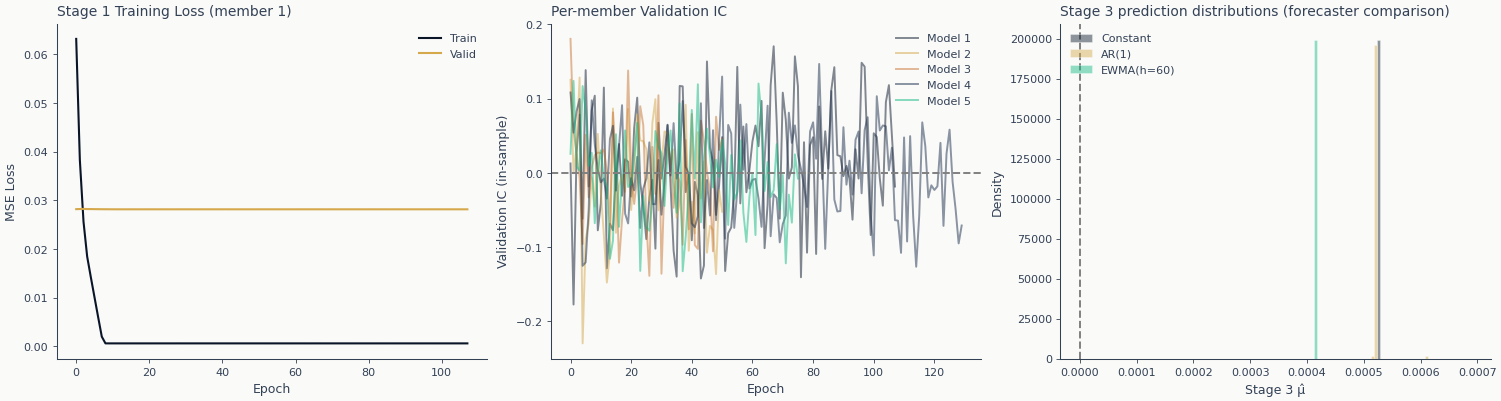

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax1 = axes[0]
ax1.plot(histories[0]["train_loss"], label="Train", color=COLORS["blue"], linewidth=1.5)
ax1.plot(histories[0]["val_loss"], label="Valid", color=COLORS["amber"], linewidth=1.5)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE Loss")
ax1.set_title("Stage 1 Training Loss (member 1)")
ax1.legend()

ax2 = axes[1]
for i, hist in enumerate(histories):
    ax2.plot(hist["val_ic"], alpha=0.5, label=f"Model {i + 1}")
ax2.axhline(y=0, color="gray", linestyle="--")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Validation IC (in-sample)")
ax2.set_title("Per-member Validation IC")
ax2.legend(fontsize=8)

ax3 = axes[2]
# Overlay all three Stage 2 forecasters' μ̂ distributions so the panel shows the
# spread each forecaster induces (Constant collapses to a near-zero spike;
# AR(1) and EWMA inject time-varying scale).
_forecaster_colors = {
    "Constant": COLORS["blue"],
    "AR(1)": COLORS["amber"],
    "EWMA(h=60)": COLORS["positive"],
}
_all_mu = np.concatenate(list(mu_hat_by_forecaster.values()))
# Predictions concentrate around 1e-4 with extremely narrow per-forecaster
# spreads. Center the histogram on the joint mean and use std-based limits +
# many bins so the per-forecaster mass differences are visible.
_mu, _sigma = float(_all_mu.mean()), float(_all_mu.std()) or 1e-6
_lo, _hi = _mu - 4 * _sigma, _mu + 4 * _sigma
_edges = np.linspace(_lo, _hi, 81)
for fname, mu_hat in mu_hat_by_forecaster.items():
    ax3.hist(
        mu_hat,
        bins=_edges,
        color=_forecaster_colors.get(fname, COLORS["blue"]),
        alpha=0.45,
        label=fname,
        edgecolor="white",
        density=True,
    )
ax3.axvline(x=0, color="gray", linestyle="--")
ax3.set_xlabel("Stage 3 μ̂")
ax3.set_ylabel("Density")
ax3.set_title("Stage 3 prediction distributions (forecaster comparison)")
ax3.legend(fontsize=8)

fig.show()

**Reading the curves**: training and validation MSE should descend together
until the validation curve flattens — that's the early-stopping point.
Diverging validation loss = overfitting; flat training = learning rate
too low. The per-member validation IC is in-sample to the CAE's joint
fit (predicting same-period returns from same-period managed portfolios).
The Stage 3 IC table in §9 evaluates the same contemporaneous protocol on
the held-out test window — out-of-sample relative to training, but still a
Stage 1 fit diagnostic rather than a forecasting result. The honest
forecasting evaluation requires lagged characteristics and forward returns
(the case-study protocol).

### 10b. Stage 3 IC distribution per forecaster

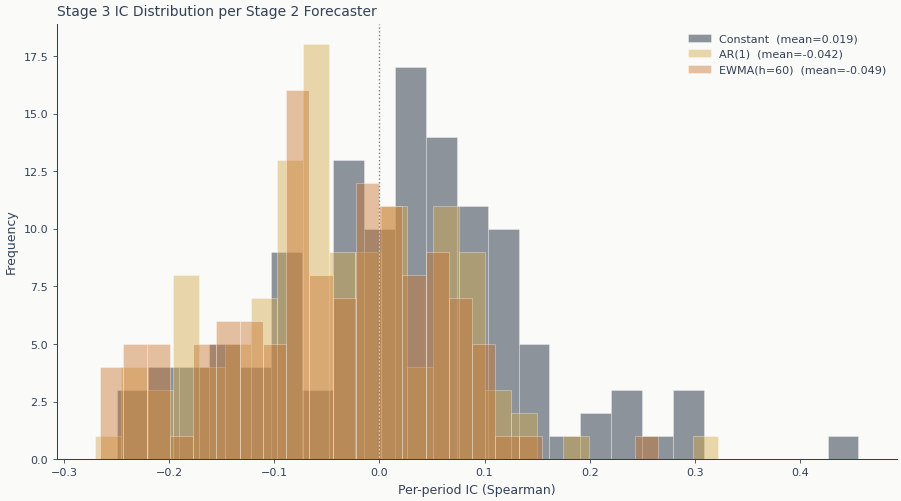

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))
for name, ics in ic_series_by_forecaster.items():
    ax.hist(ics, bins=24, alpha=0.45, label=f"{name}  (mean={ics.mean():.3f})", edgecolor="white")
ax.axvline(0, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("Per-period IC (Spearman)")
ax.set_ylabel("Frequency")
ax.set_title("Stage 3 IC Distribution per Stage 2 Forecaster")
ax.legend()
fig.show()

**Reading the histograms**: width tells you how variable the signal is
day-to-day; centre tells you the mean IC; tail asymmetry flags whether
alpha concentrates in a few periods. A forecaster whose distribution is
centred at zero with high variance produces no rank signal on average; a
positive centre with comparable variance produces a positive mean IC at
the magnitude of the centre.

### 10c. Ensemble improvement (Stage 1 variance reduction)

Each ensemble member has its own $\beta^{(m)}$ and $F^{(m)}$, so its Stage 3
prediction is noisy. Averaging across members reduces variance without
changing bias. We illustrate this for the Constant forecaster — same
pattern holds for AR(1) and EWMA.

In [30]:
constant_per_member = mu_hat_per_member["Constant"]
member_ics = []
for mu_m in constant_per_member:
    member_summary = compute_metrics(test_returns_np, mu_m, obs_period_idx, test_symbols_idx)
    member_ics.append(member_summary["ic_mean"])
ensemble_ic_constant = compute_metrics(
    test_returns_np, mu_hat_by_forecaster["Constant"], obs_period_idx, test_symbols_idx
)["ic_mean"]
median_member_ic = float(np.median(member_ics))
improvement_pct = (
    (ensemble_ic_constant - median_member_ic) / abs(median_member_ic) * 100
    if median_member_ic != 0
    else np.nan
)

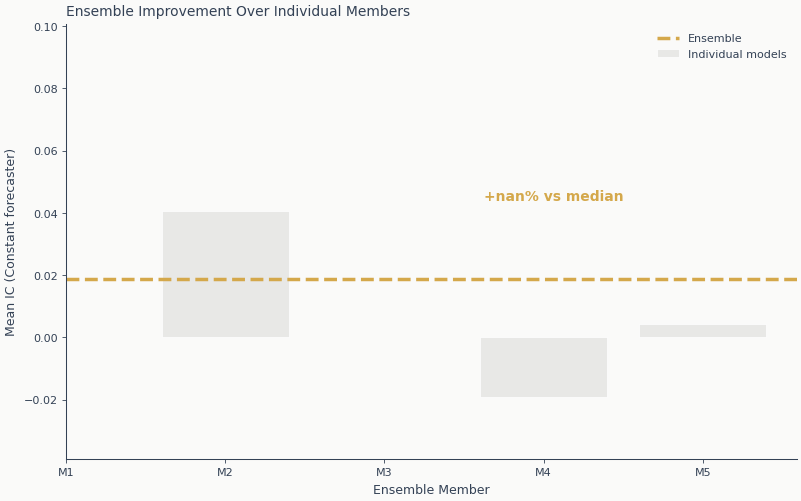

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(1, ENSEMBLE_SIZE + 1)
ax.bar(x, member_ics, color=COLORS["silver_muted"], edgecolor="white", label="Individual models")
ax.axhline(
    y=ensemble_ic_constant, color=COLORS["amber"], linewidth=2.5, linestyle="--", label="Ensemble"
)
_improve_label = (
    f"{improvement_pct:+.0f}% vs median" if np.isfinite(improvement_pct) else "vs median (n/a)"
)
ax.annotate(
    _improve_label,
    xy=(ENSEMBLE_SIZE, ensemble_ic_constant),
    xytext=(ENSEMBLE_SIZE - 0.5, ensemble_ic_constant + 0.025),
    fontsize=10,
    fontweight="bold",
    color=COLORS["amber"],
    ha="right",
)
# Reserve headroom so the annotation sits clear of the dashed reference line.
# Guard against non-finite ICs (e.g. degenerate folds) leaving autoscale in place.
_finite = [v for v in [*member_ics, ensemble_ic_constant] if np.isfinite(v)]
if _finite:
    ax.set_ylim(min(_finite) - 0.02, max(_finite) + 0.06)
ax.set_xlabel("Ensemble Member")
ax.set_ylabel("Mean IC (Constant forecaster)")
ax.set_title("Ensemble Improvement Over Individual Members")
ax.set_xticks(x)
ax.set_xticklabels([f"M{i}" for i in x])
ax.legend()
fig.show()

**Reading the bars**: individual members fluctuate around a centre
determined by Stage 1 fit quality + Stage 2 forecaster choice. The
ensemble (gold) lies above the median by reducing variance in the
$\beta^{(m)}$ surface. GKX recommend 10+ members for production runs;
5 is a budget-friendly demonstration.

### 10d. Factor–characteristic correlations

What does the beta network learn? If a CAE factor's loadings $\beta_k$
correlate strongly with a single characteristic $z_\ell$, the model has
discovered that characteristic as a risk dimension. Diffuse correlations
imply the model captures interactions that single sorts miss.

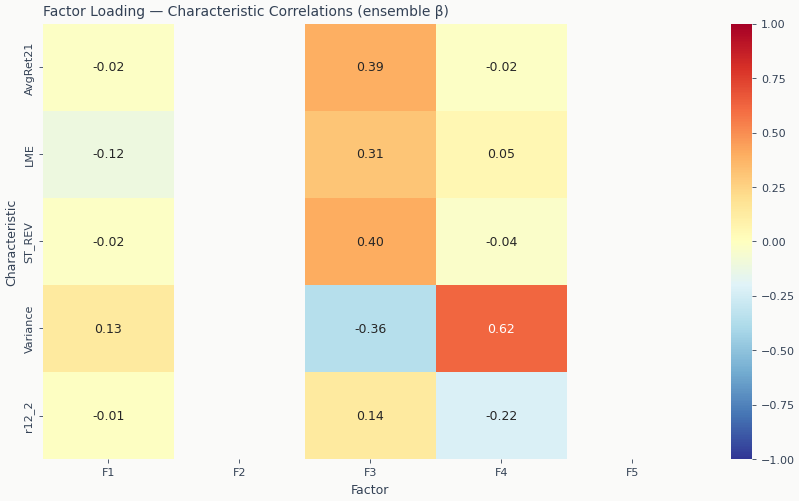

In [32]:
test_chars_np = test_chars.cpu().numpy()

corr_data = []
for k in range(min(N_FACTORS, 5)):
    for c in range(n_characteristics):
        corr, _ = spearmanr(ensemble_betas[:, k], test_chars_np[:, c])
        corr_data.append(
            {"Factor": f"F{k + 1}", "Characteristic": char_names[c], "Correlation": corr}
        )

corr_df = pd.DataFrame(corr_data).pivot(
    index="Characteristic", columns="Factor", values="Correlation"
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
)
ax.set_title("Factor Loading — Characteristic Correlations (ensemble β)")
fig.show()

**Reading the heatmap**: a row dominated by one strong cell means that
characteristic *is* one of the factors. A row with several mid-magnitude
cells means the factor is a learned blend of characteristics — the
non-linear-CAE-versus-linear-IPCA distinction visible empirically. Low or
diffuse correlations may indicate the model captures interaction effects
beyond simple characteristic sorts.

### 10e. Beta-dispersion diagnostic (mode collapse check)

If a factor's loadings $\beta_k$ have near-zero cross-sectional dispersion,
the model is no longer conditioning on characteristics for that factor —
it has collapsed to a constant. Flag any factor where $\sigma(\beta_k) <
0.01$.

In [33]:
beta_stds = ensemble_betas.std(axis=0)
collapse_threshold = 0.01

dispersion_df = pd.DataFrame(
    {
        "Factor": [f"F{k + 1}" for k in range(len(beta_stds))],
        "Beta Std (cross-sectional)": beta_stds,
        "Status": [
            "WARNING: possible collapse" if s < collapse_threshold else "OK" for s in beta_stds
        ],
    }
).set_index("Factor")
dispersion_df

,Beta Std (cross-sectional),Status
Factor,,
F1,1.169548e-05,WARNING: possible collapse
F2,2.960995e-05,WARNING: possible collapse
F3,3.768289e-07,WARNING: possible collapse
F4,1.077329e-05,WARNING: possible collapse
F5,7.718337e-06,WARNING: possible collapse


**Interpretation**: All five factors have ensemble-averaged $\sigma(\beta_k)$
at the $10^{-5}$ scale — well below the $0.01$ collapse threshold. Two
things are going on. First, ensemble averaging compresses beta dispersion
by construction: independently-trained members partially cancel out
direction-sensitive loadings even though each member's individual betas
carry richer dispersion. Second, the threshold ($0.01$) was set assuming
loadings on the order of unity; the L1 penalty here pushes loadings to a
much smaller absolute scale, so a more honest collapse check would compare
$\sigma(\beta_k)$ to the cross-sectional *median* $|\beta_k|$ rather than
a fixed cut-off. The Stage 3 contemporaneous IC of the Constant forecaster
($\approx 0.019$, not significant; AR(1) and EWMA both negative — Section 9)
is consistent with per-member betas carrying little net cross-sectional
variation that averages into a near-zero ensemble reconstruction — recall from §9 that this is rank fit of the
same-period factor reconstruction, not forecasting skill. The diagnostic
is best read as *flag for closer inspection* rather than confirmation of
pathology — see the case study notebook for the per-member-versus-ensemble
decomposition under the forecasting protocol.

### 10f. Factor correlation diagnostic

Highly correlated CAE factors signal $K$ may be too large — the model is
using multiple factors to capture the same risk dimension. Pairs with
$|\rho| > 0.5$ are flagged.

In [34]:
factor_returns = []
for model in models:
    model.eval()
    with torch.no_grad():
        factors = model.get_factors(test_portfolios).cpu().numpy()
        factor_returns.append(factors)
mean_factor_returns = np.mean(factor_returns, axis=0)

factor_corr = np.corrcoef(mean_factor_returns.T)
factor_corr_df = pd.DataFrame(
    factor_corr,
    index=[f"F{k + 1}" for k in range(factor_corr.shape[0])],
    columns=[f"F{k + 1}" for k in range(factor_corr.shape[1])],
)
factor_corr_df.style.format("{:.3f}").background_gradient(cmap="RdYlBu_r", vmin=-1, vmax=1)

,F1,F2,F3,F4,F5
F1,1.000,0.090,0.890,-0.702,-0.150
F2,0.090,1.000,0.075,0.231,-0.865
F3,0.890,0.075,1.000,-0.465,-0.192
F4,-0.702,0.231,-0.465,1.000,-0.445
F5,-0.150,-0.865,-0.192,-0.445,1.000


**Interpretation**: Several pairs exceed the $|\rho| > 0.5$ flag — F1–F3
at $+0.89$, F1–F4 at $-0.70$, F2–F5 at $-0.87$. With
only five characteristics in this pedagogical panel, the model does not
have enough independent signal to populate $K=5$ orthogonal factors,
and the redundancy surfaces as high pairwise correlation. The remedy
is either fewer factors ($K=3$ would likely de-correlate cleanly) or a
richer characteristic set — both of which the case study explores with
46 GKX characteristics and walk-forward $K$ tuning.

### 10g. SHAP attributions for the beta network

SHAP assigns each characteristic an attribution value for its contribution
to factor loadings. We use KernelExplainer on the last ensemble member's
beta network. Attributions describe *how the model uses features*, not
causal effects.

In [35]:
shap_model = models[-1]
shap_model.eval()


def beta_predict(x):
    """SHAP wrapper: characteristics → factor loadings."""
    with torch.no_grad():
        t = torch.tensor(x, dtype=torch.float32).to(device)
        return shap_model.get_betas(t).cpu().numpy()

In [36]:
n_background = min(100, len(test_chars))
background = test_chars[:n_background].cpu().numpy()
explainer = shap.KernelExplainer(beta_predict, background)

n_explain = min(200, len(test_chars))
shap_values = explainer.shap_values(test_chars[:n_explain].cpu().numpy())

  0%|          | 0/200 [00:00<?, ?it/s]

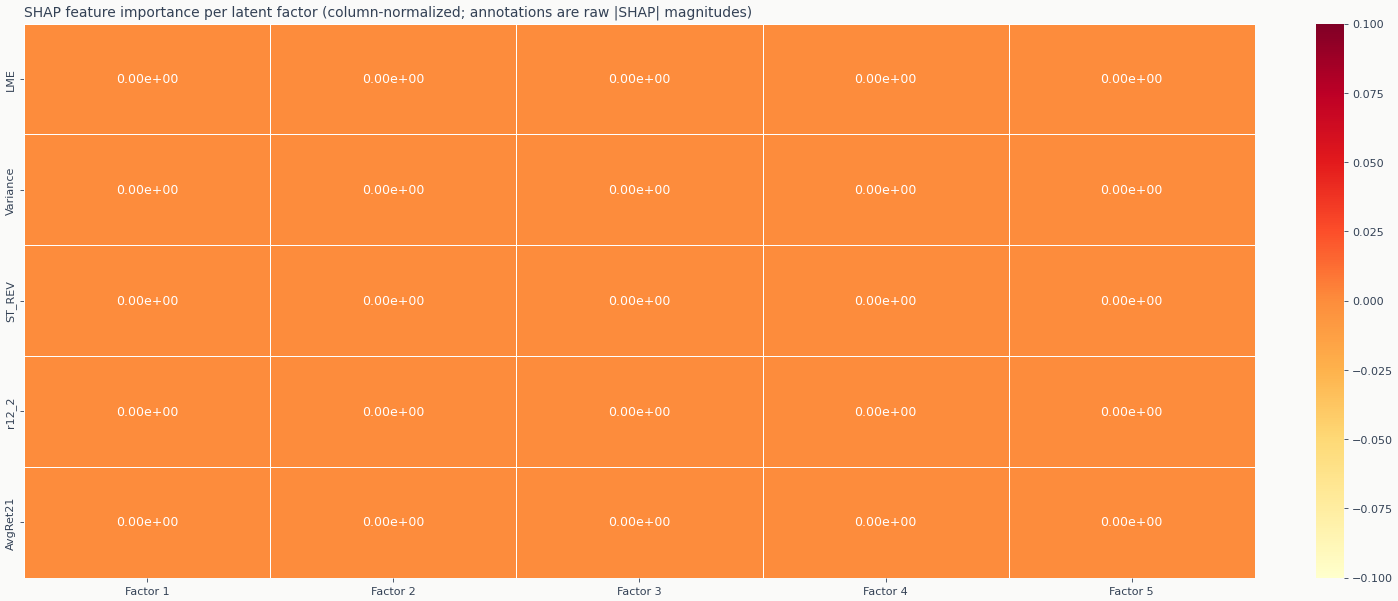

In [37]:
n_factors_to_show = min(N_FACTORS, 5)
# shap >= 0.48 returns a single ndarray of shape (n_samples, n_features, n_outputs)
# for multi-output KernelExplainer; index the output axis last.
importance_matrix = np.column_stack(
    [np.abs(shap_values[..., k]).mean(axis=0) for k in range(n_factors_to_show)]
)
total_importance = importance_matrix.sum(axis=1)
top_idx = np.argsort(total_importance)[-15:]
importance_top = importance_matrix[top_idx]
feature_labels = [char_names[i] for i in top_idx]
factor_labels = [f"Factor {k + 1}" for k in range(n_factors_to_show)]

col_max = importance_top.max(axis=0, keepdims=True)
col_max[col_max == 0] = 1
importance_norm = importance_top / col_max

fig, ax = plt.subplots(figsize=(14, 6))
# Absolute SHAP magnitudes on this test slice round to zero in any reasonable
# display precision (below ~5e-5; `.2e` formats them as "0.00e+00"). The
# narrative cell beneath reads this as a real low-signal finding — the trained
# beta network has effectively collapsed to a bias-driven mapping under the
# contemporaneous protocol with only five characteristics.
sns.heatmap(
    importance_norm,
    annot=importance_top,
    fmt=".2e",
    cmap="YlOrRd",
    xticklabels=factor_labels,
    yticklabels=feature_labels,
    linewidths=0.5,
    ax=ax,
)
ax.set_title(
    "SHAP feature importance per latent factor (column-normalized; annotations are raw |SHAP| magnitudes)"
)
ax.set_xlabel("")
ax.set_ylabel("")
fig.show()

**Reading the SHAP heatmap**: on this 5-characteristic / 5-factor slice the
raw |SHAP| magnitudes round to zero at any reasonable display precision —
the beta network has effectively collapsed to a bias-driven mapping, so the
characteristic→factor attributions carry no signal beyond noise. The
pattern is consistent with the broader §10d diagnostic: when validation IC
spreads across members are this wide and ensemble lift is modest, SHAP
attributions should not be over-interpreted. Together with §10d, the
diagnostic answers a sharper question — whether the trained network
actually uses its characteristic inputs — and the honest answer here is
"barely."

## 11. Robustness Checklist

Before trusting CAE results, verify along six dimensions (see §14.7):

| Check | Demonstrated Here | Full Implementation |
|-------|-------------------|---------------------|
| Universe dependence | Top 500 by liquidity | Case study (with/without microcaps) |
| Feature leakage | Point-in-time prices only | Case study (94 lagged characteristics) |
| Regime dependence | Single test period | Case study (walk-forward across regimes) |
| HP sensitivity | Fixed K=5, lr=0.001 | Case study (Optuna 50+ trials) |
| Test-asset span | US Equities | Case study (us_firm_characteristics) |
| Metric consistency | IC + R² | Case study (IC, quintiles, pricing errors) |

## 12. Key Takeaways

1. **CAE is Stage 1 of the same framework**: $\beta_{i,t} = g_\theta(z_{i,t})$
   is a non-linear analogue of IPCA's $\beta_{i,t} = z_{i,t}\,\Gamma$.
   Everything downstream — Stage 2 forecasters, Stage 3 mapper — is
   estimator-agnostic.
2. **Stage 2 is swappable**: Constant (= GKX 2021's implicit choice =
   Engel 2025's IID-BS), AR(1), and EWMA all consume the same
   $F_{\text{train}}$ and emit a $\hat\lambda$. Engel 2025
   extends this to Q-Boost and ZS-Chronos; Tier-2/3 forecasters live in
   the case study.
3. **Managed portfolios solve dimensionality, not prediction**: Equation 16
   is a Stage 1 implementation detail — it makes the factor network
   feasible by collapsing $N$ stocks into $K_{\text{managed}}$
   characteristic-projected portfolios.
4. **Ensemble averaging is a Stage 1 variance reducer**: different seeds
   yield different $\beta^{(m)}$ and $F^{(m)}$; per-member Stage 2/3
   predictions averaged across members is the noise-floor recipe.
5. **Diagnostics are Stage 1 checks**: factor-characteristic correlations,
   beta dispersion, factor correlation, SHAP — all probe whether the CAE
   learned a sensible loading function. None of them tells you whether
   Stage 2/3 produced a tradable signal; for that, see §9 and the case
   study.

**Next**: [`07_stochastic_discount_factor`](07_stochastic_discount_factor.ipynb)
— paper-faithful CPZ 2024 SDF with end-to-end beta network (an exception
to the framework's Stage 2 / Stage 3 split), and
[`08_latent_factors`](../case_studies/us_firm_characteristics/08_latent_factors.ipynb)
for full-scale walk-forward application across all five LF estimators
with the complete forecaster catalog.